<a href="https://colab.research.google.com/github/Sambuddha10/telco-churn-prediction/blob/main/notebooks/01_eda_and_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

url ="https://raw.githubusercontent.com/Sambuddha10/telco-churn-prediction/refs/heads/main/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [27]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [28]:
missing_values = df.isnull().sum().sort_values(ascending=False)

print("Missing values in each column:")
missing_values[missing_values > 0]

Missing values in each column:


,0


In [29]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values after conversion:")
print(df["TotalCharges"].isnull().sum())

df[df["TotalCharges"].isnull()].head()

Missing values after conversion:
11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No


In [30]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("TotalCharges data type:", df["TotalCharges"].dtype)
print("Missing TotalCharges values:", df["TotalCharges"].isnull().sum())

TotalCharges data type: float64
Missing TotalCharges values: 0


In [31]:
churn_summary = pd.DataFrame({
    "Customer Count": df["Churn"].value_counts(),
    "Percentage": (df["Churn"].value_counts(normalize=True) * 100).round(2)
})

churn_summary

,Customer Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


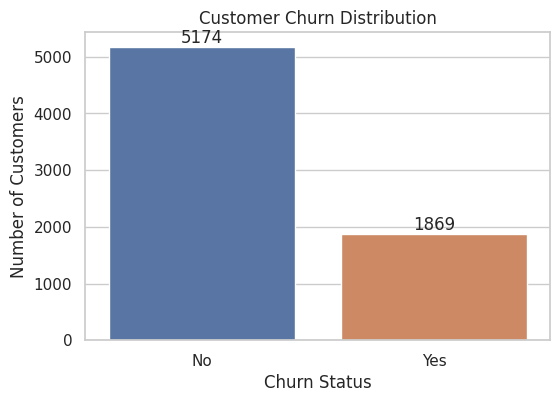

In [32]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="Churn", hue="Churn", legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

# Exploratory Data Analysis

This section explores customer characteristics, account information, and services associated with customer churn.

In [33]:
churn_counts = df["Churn"].value_counts()

churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churn_summary = pd.DataFrame({
    "Customer Count": churn_counts,
    "Percentage (%)": churn_percentage
})

churn_summary

,Customer Count,Percentage (%)
Churn,,
No,5174,73.46
Yes,1869,26.54


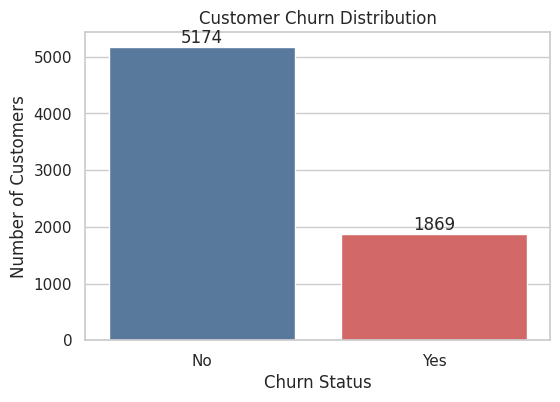

In [34]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    legend=False,
    palette=["#4C78A8", "#E45756"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

## Churn rate by contract type

In [35]:
contract_churn = (
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


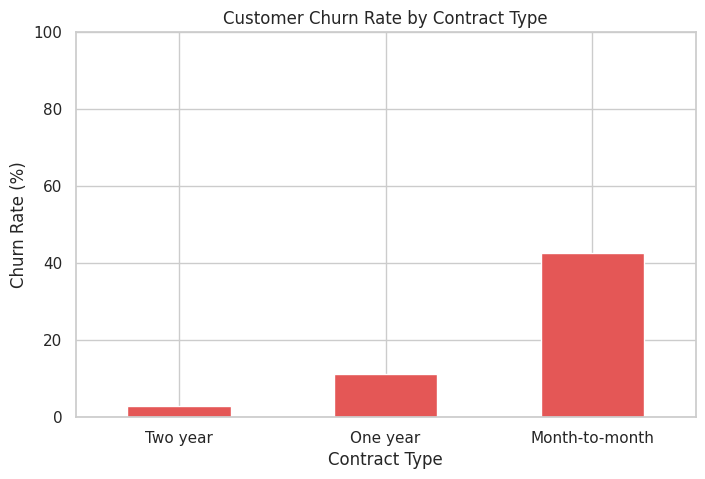

In [36]:
contract_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8, 5),
    color="#E45756"
)

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

## Customer tenure and churn

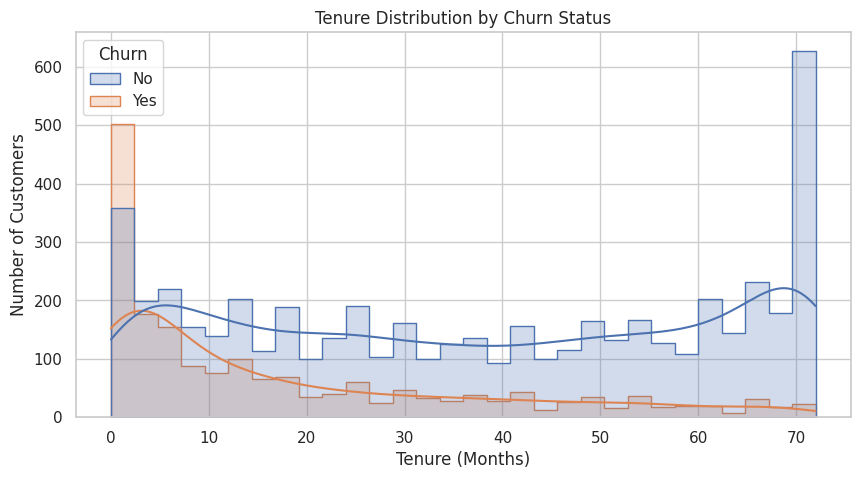

In [37]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    element="step",
    stat="count",
    common_norm=False
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

In [38]:
tenure_summary = (
    df.groupby("Churn")["tenure"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

tenure_summary

,count,mean,median,min,max
Churn,,,,,
No,5174,37.57,38.0,0,72
Yes,1869,17.98,10.0,1,72


## Monthly charges and churn

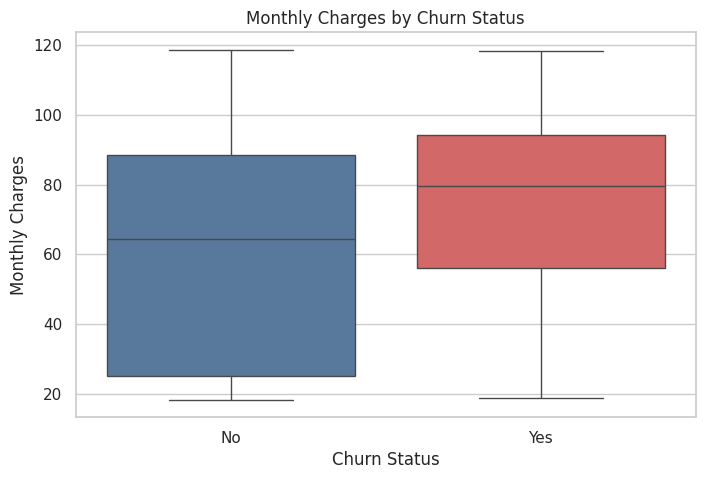

In [39]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    legend=False,
    palette=["#4C78A8", "#E45756"]
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")
plt.show()


In [40]:
charge_summary = (
    df.groupby("Churn")["MonthlyCharges"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

charge_summary

,count,mean,median,min,max
Churn,,,,,
No,5174,61.27,64.43,18.25,118.75
Yes,1869,74.44,79.65,18.85,118.35


## Churn rate by payment method

In [41]:
payment_churn = (
    pd.crosstab(
        df["PaymentMethod"],
        df["Churn"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

payment_churn


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


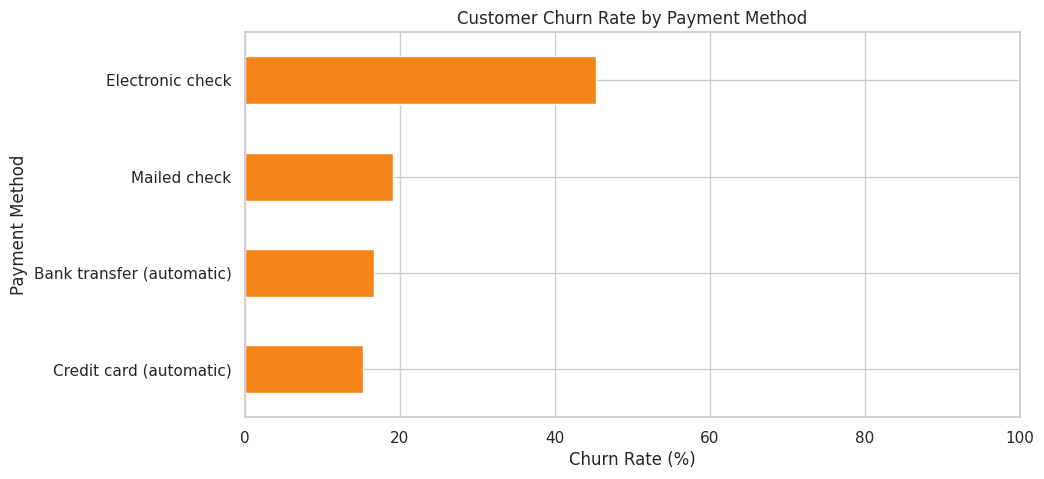

In [42]:
payment_churn["Yes"].sort_values().plot(
    kind="barh",
    figsize=(10, 5),
    color="#F58518"
)

plt.title("Customer Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")
plt.xlim(0, 100)
plt.show()


## Churn rate by internet service

In [43]:
internet_churn = (
    pd.crosstab(
        df["InternetService"],
        df["Churn"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


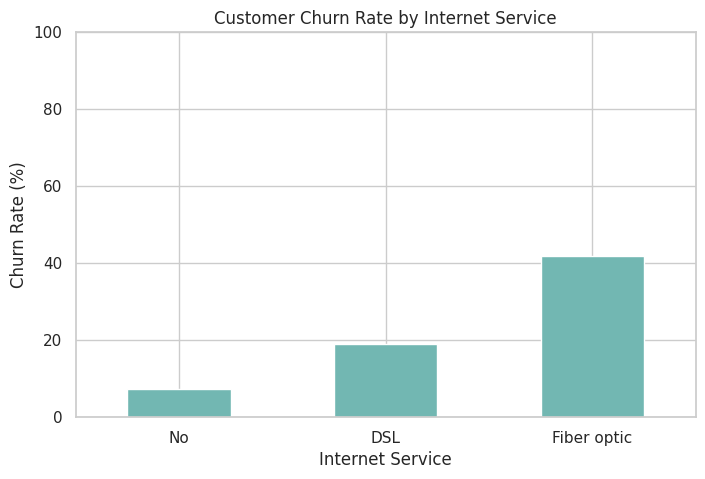

In [44]:
internet_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8, 5),
    color="#72B7B2"
)

plt.title("Customer Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

## Key EDA Findings

1. The dataset contains [TOTAL] customers. The churn rate is [CHURN RATE]%, which means the target classes are not perfectly balanced. Therefore, model evaluation will include recall, precision, F1-score, and ROC-AUC instead of accuracy alone.

2. Month-to-month contract customers have the highest churn rate at [VALUE]%, while [LOWEST-CONTRACT-TYPE] customers have the lowest churn rate at [VALUE]%. This indicates that longer commitments are associated with lower churn.

3. Churned customers have average tenure of [VALUE] months, compared with [VALUE] months for customers who stayed. Customers are most vulnerable to churn early in their relationship with the company.

4. The average monthly charge is [VALUE] for churned customers and [VALUE] for retained customers. This suggests pricing or service-value perception may be related to churn.

5. [PAYMENT METHOD] shows the highest churn rate. This segment should be investigated for billing experience, customer preferences, or plan characteristics.

6. [INTERNET SERVICE] customers show the highest churn rate. The company should investigate service quality, price competitiveness, and customer support for this group.